# Prédiction des Incidents Maritimes

## Plan du Notebook

### 1. Analyse des Données
- Import des librairies et données
- EDA (statistiques descriptives, visualisations)
- Analyse du déséquilibre des classes

### 2. Préparation des Données
- Nettoyage et formatage des données
- Feature Engineering avancé
- Sélection des features

### 3. Entraînement et Évaluation des Modèles
- Construction du pipeline de bout en bout
- Modèles de base (baseline)
- Stratégies d'amélioration (SMOTE, Class Weights, Anomaly Detection)

### 4. Sélection de Modèle et Optimisation des Hyperparamètres
- Optimisation des hyperparamètres
- Modèles d'ensemble (Voting, Stacking)
- Comparaison finale

### 5. Analyse des Erreurs et Interprétabilité
- Analyse des performances
- Importance des Features et SHAP
- Visualisations

### 6. Déploiement du Modèle
- Sauvegarde du meilleur modèle
- Recommandations d'utilisation

---

## Stratégies d'Amélioration Appliquées
1. **SMOTE** - Suréchantillonnage synthétique de la classe minoritaire
2. **Ajustement des seuils de décision** - Ne pas utiliser 0.5 par défaut
3. **Poids de classes** - Pondération forte de la classe minoritaire
4. **Métriques adaptées** - Focus sur Recall et PR-AUC (pas Accuracy)
5. **Validation croisée stratifiée** avec réplication des incidents
6. **Approche détection d'anomalies** - OneClassSVM, IsolationForest


## 1. ANALYSE DES DONNÉES


### 1.1 Import des Librairies

In [1]:
# 1. IMPORT DES LIBRAIRIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Sklearn - Modèles classiques
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Sklearn - Métriques
from sklearn.metrics import ( confusion_matrix, make_scorer,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, accuracy_score)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print(" XGBoost non installé")

import joblib

print(" Librairies importées avec succès")

 Librairies importées avec succès


### 1.2 Chargement des Données et Analyse Exploratoire (EDA)

In [2]:
# 2. IMPORT DES DATASETS
print(" CHARGEMENT DES DONNÉES")
print("=" * 60)

# Charger les datasets train et test (déjà créés par le notebook 2.3)
train = pd.read_csv('../data/dataset_train.csv')
test = pd.read_csv('../data/dataset_test.csv')

print(f"Dataset train: {train.shape}")
print(f"Dataset test: {test.shape}")

# Aperçu des colonnes originales
print(f"\n Colonnes originales: {len(train.columns)}")
print(f"   Features météo: {len([c for c in train.columns if 'vent' in c or 'mer' in c or 'temps' in c])}")
print(f"   Features temporelles: {len([c for c in train.columns if 'jour' in c or 'mois' in c or 'annee' in c])}")

# Analyse du déséquilibre
y_train_temp = train['incident']
y_test_temp = test['incident']

print(f"\n ANALYSE DU DÉSÉQUILIBRE:")
print(f"   Train: {len(train)} observations")
print(f"      - Incidents (1): {y_train_temp.sum()} ({100*y_train_temp.mean():.1f}%)")
print(f"      - Non-incidents (0): {(y_train_temp == 0).sum()} ({100*(1-y_train_temp.mean()):.1f}%)")
print(f"   Test: {len(test)} observations")
print(f"      - Incidents (1): {y_test_temp.sum()} ({100*y_test_temp.mean():.1f}%)")
print(f"   Ratio train: {(y_train_temp == 0).sum() / max(1, y_train_temp.sum()):.1f}:1")



 CHARGEMENT DES DONNÉES
Dataset train: (1076, 99)
Dataset test: (270, 99)

 Colonnes originales: 99
   Features météo: 28
   Features temporelles: 9

 ANALYSE DU DÉSÉQUILIBRE:
   Train: 1076 observations
      - Incidents (1): 134 (12.5%)
      - Non-incidents (0): 942 (87.5%)
   Test: 270 observations
      - Incidents (1): 34 (12.6%)
   Ratio train: 7.0:1



 VISUALISATIONS EXPLORATOIRES


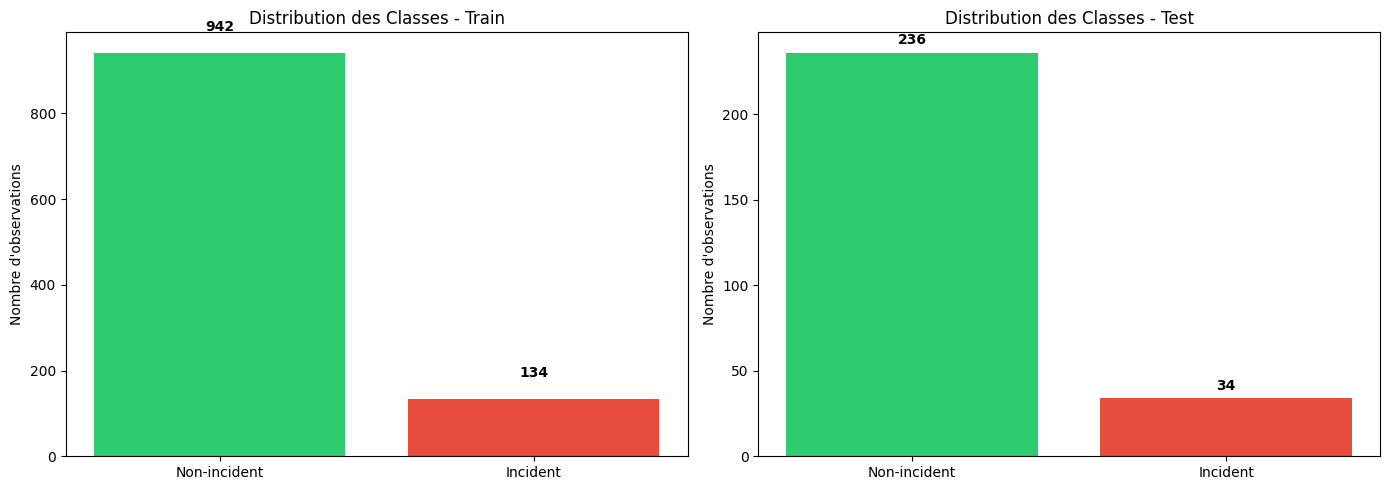

In [3]:
# VISUALISATIONS
print("\n" + "=" * 60)
print(" VISUALISATIONS EXPLORATOIRES")
print("=" * 60)

# 1. Distribution des classes (déséquilibre)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_counts = y_train_temp.value_counts()
axes[0].bar(['Non-incident', 'Incident'], train_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution des Classes - Train')
axes[0].set_ylabel('Nombre d\'observations')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Test
test_counts = y_test_temp.value_counts()
axes[1].bar(['Non-incident', 'Incident'], test_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribution des Classes - Test')
axes[1].set_ylabel('Nombre d\'observations')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



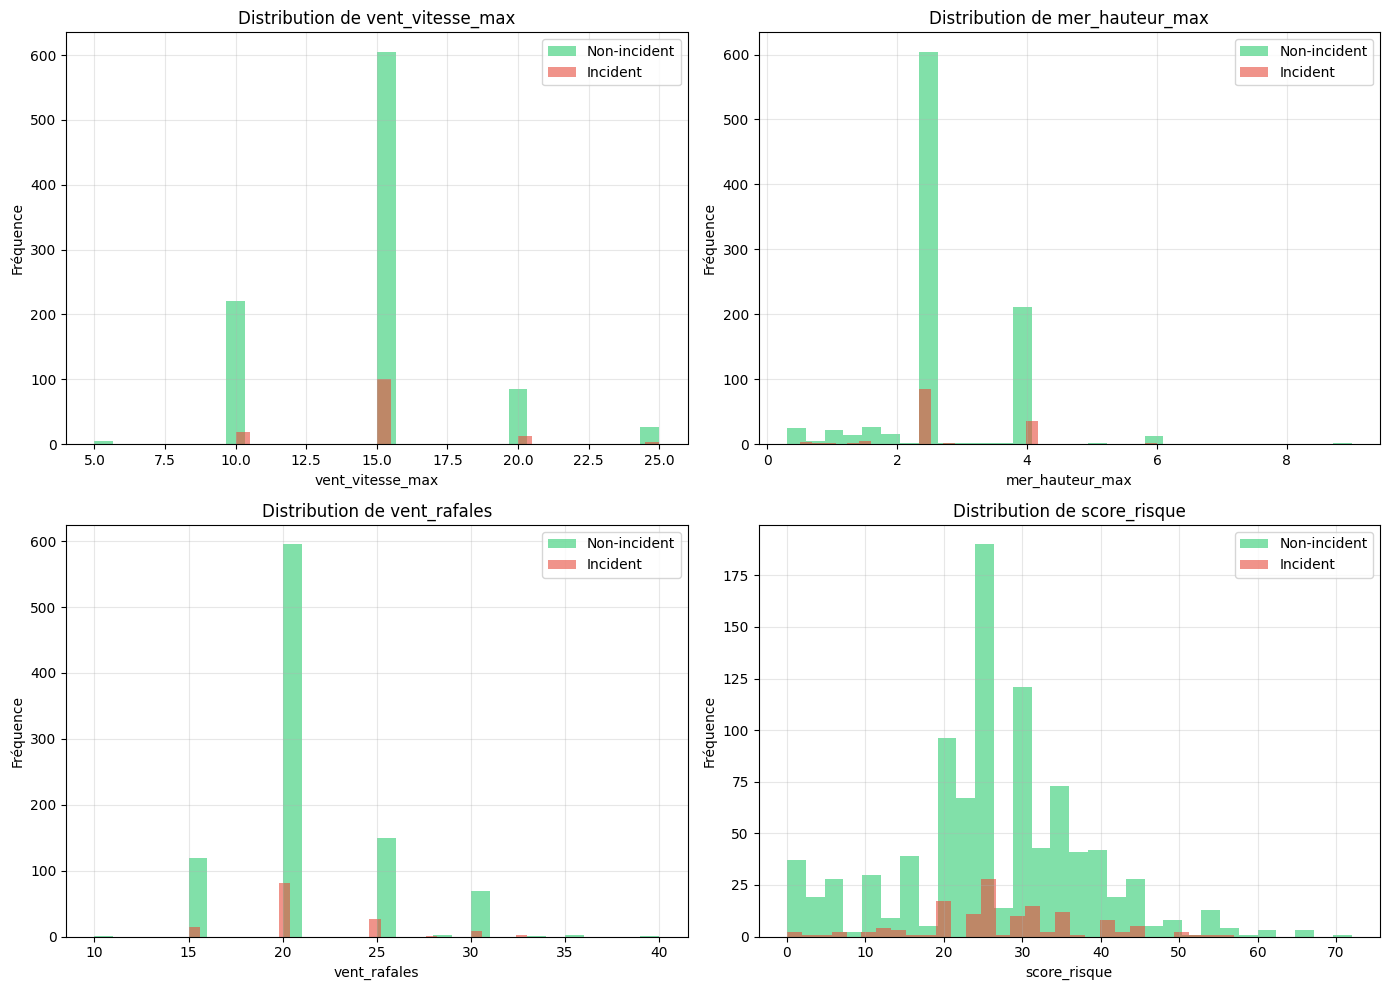

In [4]:
# 2. Distribution des variables météo principales
meteo_vars = ['vent_vitesse_max', 'mer_hauteur_max', 'vent_rafales', 'score_risque']
meteo_vars_available = [var for var in meteo_vars if var in train.columns]

if meteo_vars_available:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(meteo_vars_available[:4]):
        # Distribution pour incidents vs non-incidents
        train[train['incident']==0][var].hist(bins=30, alpha=0.6, label='Non-incident', 
                                               ax=axes[i], color='#2ecc71')
        train[train['incident']==1][var].hist(bins=30, alpha=0.6, label='Incident', 
                                               ax=axes[i], color='#e74c3c')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Fréquence')
        axes[i].set_title(f'Distribution de {var}')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()



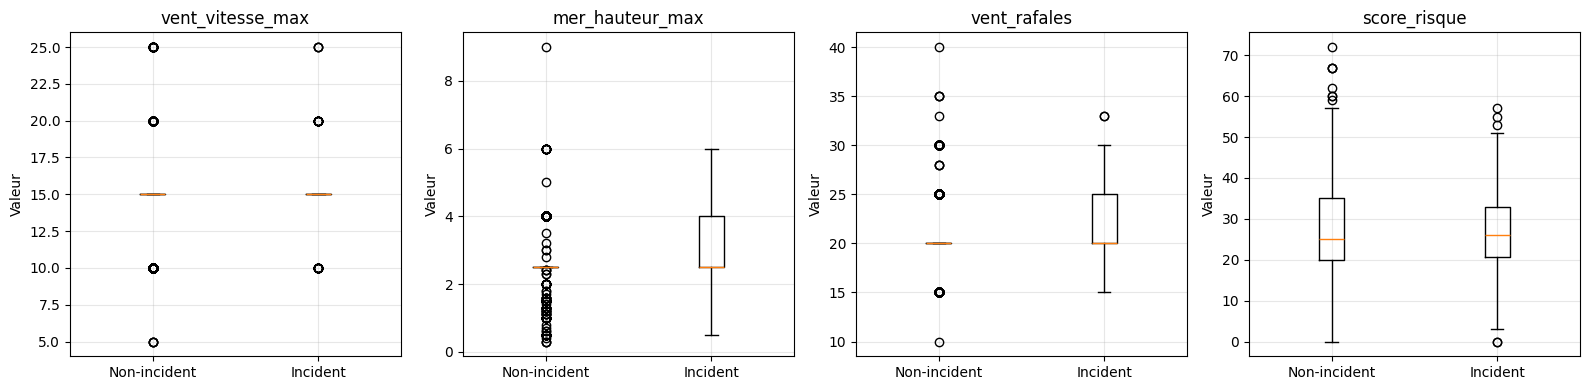

In [5]:
# 3. Boxplots des variables météo par classe
if meteo_vars_available:
    fig, axes = plt.subplots(1, len(meteo_vars_available[:4]), figsize=(16, 4))
    if len(meteo_vars_available) == 1:
        axes = [axes]
    
    for i, var in enumerate(meteo_vars_available[:4]):
        data_to_plot = [train[train['incident']==0][var].dropna(), 
                        train[train['incident']==1][var].dropna()]
        axes[i].boxplot(data_to_plot, labels=['Non-incident', 'Incident'])
        axes[i].set_title(var)
        axes[i].set_ylabel('Valeur')
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()



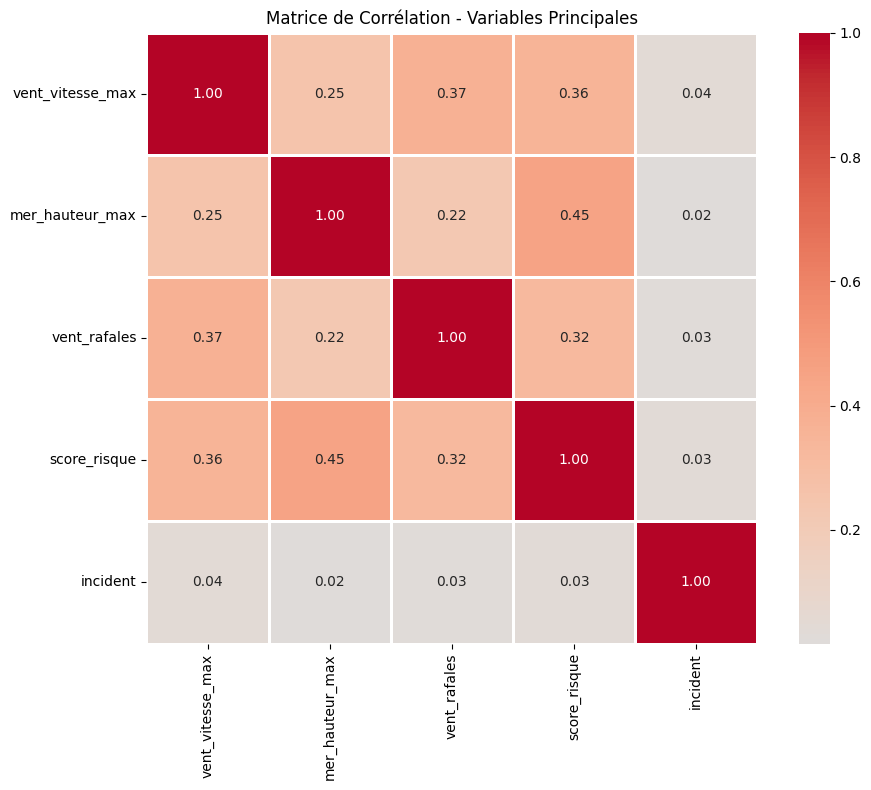

In [6]:
# 4. Corrélation entre les principales variables météo et les incidents
corr_vars = ['vent_vitesse_max', 'mer_hauteur_max', 'vent_rafales', 
             'score_risque', 'incident']
corr_vars_available = [var for var in corr_vars if var in train.columns]

if len(corr_vars_available) > 1:
    corr_matrix = train[corr_vars_available].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Matrice de Corrélation - Variables Principales')
    plt.tight_layout()
    plt.show()



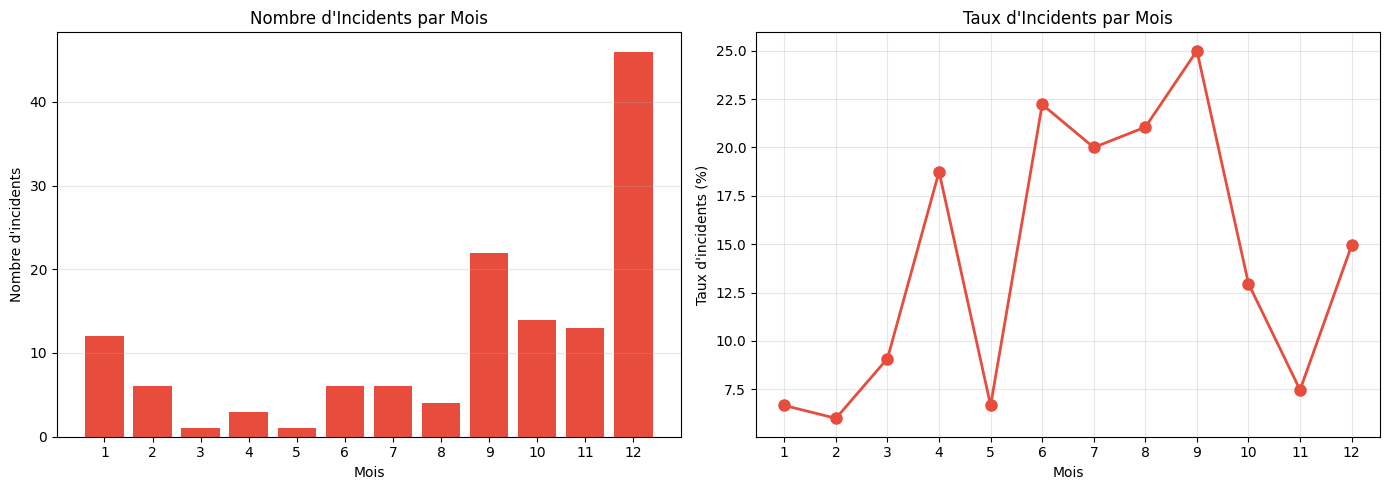


 Feature Engineering va être appliqué avant la séparation X/y...


In [7]:
# 5. Distribution temporelle des incidents
if 'mois' in train.columns:
    incidents_par_mois = train.groupby('mois')['incident'].agg(['sum', 'count', 'mean'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Nombre d'incidents par mois
    axes[0].bar(incidents_par_mois.index, incidents_par_mois['sum'], color='#e74c3c')
    axes[0].set_xlabel('Mois')
    axes[0].set_ylabel('Nombre d\'incidents')
    axes[0].set_title('Nombre d\'Incidents par Mois')
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(axis='y', alpha=0.3)
    
    # Taux d'incidents par mois
    axes[1].plot(incidents_par_mois.index, incidents_par_mois['mean'] * 100, 
                 marker='o', linewidth=2, markersize=8, color='#e74c3c')
    axes[1].set_xlabel('Mois')
    axes[1].set_ylabel('Taux d\'incidents (%)')
    axes[1].set_title('Taux d\'Incidents par Mois')
    axes[1].set_xticks(range(1, 13))
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n Feature Engineering va être appliqué avant la séparation X/y...")


## 2. PRÉPARATION DES DONNÉES


### 2.1 Feature Engineering Avancé

#### Objectifs:
1. **Features d'interaction** - Combinaisons météo dangereuses
2. **Features temporelles (lag)** - Tendances sur jours précédents
3. **Agrégations enrichies** - Ratios et coefficients de variation
4. **Features de risque composites** - Scores combinés

### 2.1.1 Création des Features d'Interaction

In [8]:
# 2.1.1 CRÉATION DES FEATURES D'INTERACTION
print(" FEATURE ENGINEERING AVANCÉ")
print("=" * 60)

def create_interaction_features(df):
    """Crée des features d'interaction entre variables météo"""
    df = df.copy()
    
    if 'nb_conditions_defavorables' not in df.columns:
        conditions_cols = [c for c in df.columns if 'precipitation' in c or 'orage' in c or 'visibilite' in c]
        if conditions_cols:
            df['nb_conditions_defavorables'] = df[conditions_cols].sum(axis=1)
    
    
    # Risque vent × mer (conditions combinées dangereuses)
    df['vent_mer_risque'] = df['vent_vitesse_max'] * df['mer_hauteur_max']
    
    # Risque rafales × hauteur mer
    df['rafale_mer_risque'] = df['vent_rafales'] * df['mer_hauteur_max']
    
    # Risque rafales × score mer
    df['rafale_score_mer'] = df['vent_rafales'] * df['mer_score_max']
    
    # Score risque × saison cyclonique
    df['score_saison'] = df['score_risque'] * df['saison_cyclonique']
    
    # Vent × précipitation (tempête)
    df['vent_precipitation'] = df['vent_vitesse_max'] * df['temps_precipitation']
    
    # Mer × visibilité réduite (danger navigation)
    df['mer_visibilite'] = df['mer_score_max'] * (1 + df['temps_visibilite_reduite'])
    

    # Coefficient de rafales (intensité relative des rafales)
    df['coef_rafales'] = df['vent_rafales'] / (df['vent_vitesse_max'] + 1)
    
    # Ratio hauteur mer max/min (variabilité)
    df['mer_ratio_max_min'] = df['mer_hauteur_max'] / (df['mer_hauteur_min'] + 0.1)
    
    # Variabilité du score mer
    df['mer_score_variabilite'] = df['mer_score_max'] - df['mer_score_min']
    
    # Coefficient de variation vent
    df['vent_cv'] = df['vent_amplitude'] / (df['vent_moyen'] + 1)
    
    # Score de danger composite (combine tous les facteurs)
    df['score_danger_composite'] = (
        df['score_risque'] * 0.3 +
        df['vent_mer_risque'] * 0.01 +  # Normalisation
        df['temps_score_danger'] * 10 +
        df['nb_conditions_defavorables'] * 5
    )
    
    # Conditions extrêmes (flags binaires)
    df['vent_extreme'] = (df['vent_vitesse_max'] >= 30).astype(int)
    df['mer_extreme'] = (df['mer_hauteur_max'] >= 4).astype(int)
    df['rafales_extremes'] = (df['vent_rafales'] >= 35).astype(int)
    df['score_critique'] = (df['score_risque'] >= 40).astype(int)
    
    
    # Jour de la semaine encodé cycliquement
    df['jour_semaine_sin'] = np.sin(2 * np.pi * df['jour_semaine'] / 7)
    df['jour_semaine_cos'] = np.cos(2 * np.pi * df['jour_semaine'] / 7)
    
    # Jour de l'année encodé cycliquement  
    df['jour_annee_sin'] = np.sin(2 * np.pi * df['jour_annee'] / 365)
    df['jour_annee_cos'] = np.cos(2 * np.pi * df['jour_annee'] / 365)
    
    # Période de l'année (trimestre)
    df['trimestre'] = ((df['mois'] - 1) // 3) + 1
    
    # Mois à haut risque (cyclones: Janvier-Mars)
    df['mois_haut_risque'] = df['mois'].isin([1, 2, 3, 12]).astype(int)
    
    return df

# Appliquer aux datasets
print(" Création des features sur train...")
train_fe = create_interaction_features(train)
print(" Création des features sur test...")
test_fe = create_interaction_features(test)

# Nouvelles colonnes créées
new_cols = [c for c in train_fe.columns if c not in train.columns]
print(f"\n {len(new_cols)} nouvelles features créées:")
for i, col in enumerate(new_cols, 1):
    print(f"   {i:2d}. {col}")

# Remplacer train et test
train = train_fe
test = test_fe

print(f"\n Dimensions finales:")
print(f"   Train: {train.shape}")
print(f"   Test: {test.shape}")

 FEATURE ENGINEERING AVANCÉ
 Création des features sur train...
 Création des features sur test...

 20 nouvelles features créées:
    1. nb_conditions_defavorables
    2. vent_mer_risque
    3. rafale_mer_risque
    4. rafale_score_mer
    5. score_saison
    6. vent_precipitation
    7. mer_visibilite
    8. coef_rafales
    9. mer_ratio_max_min
   10. mer_score_variabilite
   11. vent_cv
   12. score_danger_composite
   13. vent_extreme
   14. mer_extreme
   15. rafales_extremes
   16. score_critique
   17. jour_semaine_sin
   18. jour_semaine_cos
   19. trimestre
   20. mois_haut_risque

 Dimensions finales:
   Train: (1076, 119)
   Test: (270, 119)


#### 2.1.2 Features Temporelles (Lag)

In [9]:
# 2.1.2 FEATURES TEMPORELLES LAG (Tendances)
print(" CRÉATION DES FEATURES LAG (Tendances temporelles)")
print("=" * 60)

def create_lag_features(df, lag_cols, lags=[1, 2, 3]):
    """
    Crée des features lag et rolling pour capturer les tendances.
    Note: Les données doivent être triées par date.
    """
    df = df.copy()
    
    # Trier par date si possible (sinon on suppose que c'est déjà trié)
    if 'annee' in df.columns and 'mois' in df.columns and 'jour' in df.columns:
        df = df.sort_values(['annee', 'mois', 'jour']).reset_index(drop=True)
    
    for col in lag_cols:
        if col in df.columns:
            # Features lag (valeurs des jours précédents)
            for lag in lags:
                df[f'{col}_lag{lag}'] = df[col].shift(lag)
            
            # Rolling mean (moyenne mobile sur 3 jours)
            df[f'{col}_rolling3'] = df[col].rolling(window=3, min_periods=1).mean()
            
            # Dégradation/amélioration (différence avec jour précédent)
            df[f'{col}_diff1'] = df[col].diff(1)
            
            # Tendance sur 3 jours (pente)
            df[f'{col}_trend3'] = df[col].rolling(window=3, min_periods=2).apply(
                lambda x: (x.iloc[-1] - x.iloc[0]) / len(x) if len(x) > 1 else 0, raw=False
            )
    
    return df

# Colonnes importantes pour les tendances
lag_columns = [
    'score_risque_max',
    'vent_vitesse_max_max', 
    'mer_hauteur_max_max',
    'vent_rafales_max',
    'nb_conditions_defavorables'
]

print(" Création des features lag sur train...")
train = create_lag_features(train, lag_columns)
print(" Création des features lag sur test...")
test = create_lag_features(test, lag_columns)

# Gérer les NaN créés par les lags (remplir avec la médiane)
lag_cols_created = [c for c in train.columns if '_lag' in c or '_rolling' in c or '_diff' in c or '_trend' in c]
print(f"\n {len(lag_cols_created)} features lag créées")

# Afficher quelques stats
print(f"\n Valeurs manquantes créées par les lags:")
print(f"   Train: {train[lag_cols_created].isnull().sum().sum()} NaN (seront imputés)")
print(f"   Test: {test[lag_cols_created].isnull().sum().sum()} NaN")

# Imputer les valeurs manquantes avec la médiane
for col in lag_cols_created:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

print(f"\n Valeurs manquantes imputées avec la médiane")
print(f" Dimensions finales: Train {train.shape}, Test {test.shape}")

 CRÉATION DES FEATURES LAG (Tendances temporelles)
 Création des features lag sur train...
 Création des features lag sur test...
 Création des features lag sur test...

 14 features lag créées

 Valeurs manquantes créées par les lags:
   Train: 8 NaN (seront imputés)
   Test: 8 NaN

 Valeurs manquantes imputées avec la médiane
 Dimensions finales: Train (1076, 125), Test (270, 125)

 14 features lag créées

 Valeurs manquantes créées par les lags:
   Train: 8 NaN (seront imputés)
   Test: 8 NaN

 Valeurs manquantes imputées avec la médiane
 Dimensions finales: Train (1076, 125), Test (270, 125)


### 2.2 Sélection des Features

In [10]:
# 2.1.3 ANALYSE ET SÉLECTION DES FEATURES
print(" ANALYSE DES FEATURES")
print("=" * 60)



# Identifier les colonnes non-numériques à exclure
cols_to_exclude = ['incident']

for col in train.columns:
    if train[col].dtype == 'object' or 'date' in col.lower():
        cols_to_exclude.append(col)

cols_to_exclude = list(set(cols_to_exclude))
print(f"Colonnes exclues: {cols_to_exclude}")

# Features = colonnes numériques uniquement
feature_cols_all = [col for col in train.columns if col not in cols_to_exclude]
print(f"\n Total features disponibles: {len(feature_cols_all)}")

# Préparer les données pour l'analyse
X_analysis = train[feature_cols_all].copy()
y_analysis = train['incident'].copy()

# Remplacer inf par NaN puis imputer
X_analysis = X_analysis.replace([np.inf, -np.inf], np.nan)
X_analysis = X_analysis.fillna(X_analysis.median())

# Sélection univariée avec F-test
selector = SelectKBest(f_classif, k='all')
selector.fit(X_analysis, y_analysis)

# Créer un DataFrame des scores
feature_scores = pd.DataFrame({
    'feature': feature_cols_all,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print(f"\n TOP 25 FEATURES (par F-score):")
print(feature_scores.head(25).to_string(index=False))

# Sélectionner les meilleures features (p_value < 0.1 ou top 40)
significant_features = feature_scores[feature_scores['p_value'] < 0.1]['feature'].tolist()
top_features = feature_scores.head(40)['feature'].tolist()

# Utiliser l'union des deux
selected_features = list(set(significant_features + top_features))
print(f"\n Features sélectionnées: {len(selected_features)}")

# Mettre à jour feature_cols pour la suite
feature_cols = selected_features
print(f"   (Features significatives ou top 40)")

 ANALYSE DES FEATURES
Colonnes exclues: ['incident']

 Total features disponibles: 124

 TOP 25 FEATURES (par F-score):
                               feature   f_score  p_value
                     saison_cyclonique 13.115501 0.000307
                        jour_annee_cos 11.559844 0.000699
                              mois_sin 10.363603 0.001324
                    vent_precipitation  8.404581 0.003819
   nb_conditions_defavorables_rolling3  8.395113 0.003839
                              mois_cos  8.332853 0.003971
                   temps_precipitation  7.660858 0.005740
                          score_saison  7.330803 0.006886
                                 annee  7.326268 0.006903
            zone_CAP D'AMBRE A CAP EST  7.299608 0.007006
                            jour_annee  7.208454 0.007368
          zone_MANANJARAY A TAOLAGNARO  7.069542 0.007957
     zone_ANTALAHA AU CAP SAINTE-MARIE  7.069542 0.007957
                                  mois  6.690169 0.009825
          

### 2.3 Préparation Finale des Données (X/y Split)

In [11]:
# 2.1.4 SÉPARATION X/Y FINALE
print(" PRÉPARATION FINALE DES DONNÉES")
print("=" * 60)

# Séparation X et y avec les nouvelles features
X_train = train[feature_cols].copy()
y_train = train['incident'].copy()
X_test = test[feature_cols].copy()
y_test = test['incident'].copy()

# Nettoyer les valeurs infinies
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imputer les valeurs manquantes avec la médiane
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

print(f" Données prêtes pour la modélisation:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape} ({y_train.sum()} incidents)")
print(f"   y_test: {y_test.shape} ({y_test.sum()} incidents)")
print(f"\n Features utilisées: {len(feature_cols)}")
print(f"   (après Feature Engineering et sélection)")

 PRÉPARATION FINALE DES DONNÉES
 Données prêtes pour la modélisation:
   X_train: (1076, 40)
   X_test: (270, 40)
   y_train: (1076,) (134 incidents)
   y_test: (270,) (34 incidents)

 Features utilisées: 40
   (après Feature Engineering et sélection)



## 3. ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES


### 3.1 Stratégie 1: SMOTE + Classification avec Seuil Ajusté

SMOTE crée des exemples synthétiques pour équilibrer le dataset. On ajuste aussi le seuil de décision.

#### 3.1.1 Application de SMOTE

In [12]:
# 3.1 Application de SMOTE
print(" APPLICATION DE SMOTE")
print("=" * 60)

# Vérifier et nettoyer les données
print(f"Types de colonnes: {X_train.dtypes.value_counts().to_dict()}")

# S'assurer qu'il n'y a que des numériques
X_train_clean = X_train.select_dtypes(include=[np.number])
X_test_clean = X_test.select_dtypes(include=[np.number])

print(f"Features numériques: {len(X_train_clean.columns)}")

# Gérer les valeurs manquantes
if X_train_clean.isnull().sum().sum() > 0:
    print(" Valeurs manquantes détectées, imputation par médiane...")
    X_train_clean = X_train_clean.fillna(X_train_clean.median())
    X_test_clean = X_test_clean.fillna(X_test_clean.median())

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# SMOTE - On génère des exemples synthétiques
n_minority = y_train.sum()
k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1

print(f"\nIncidents dans train: {n_minority}")
print(f"k_neighbors pour SMOTE: {k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n AVANT SMOTE:")
print(f"   Non-incidents: {(y_train == 0).sum()}")
print(f"   Incidents: {(y_train == 1).sum()}")

print(f"\n APRÈS SMOTE:")
print(f"   Non-incidents: {(y_train_smote == 0).sum()}")
print(f"   Incidents: {(y_train_smote == 1).sum()}")
print(f"   Ratio maintenant: 1:1 ")

# Mettre à jour feature_cols avec les colonnes numériques
feature_cols = X_train_clean.columns.tolist()

 APPLICATION DE SMOTE
Types de colonnes: {dtype('float64'): 20, dtype('int64'): 13, dtype('bool'): 7}
Features numériques: 33

Incidents dans train: 134
k_neighbors pour SMOTE: 5

 AVANT SMOTE:
   Non-incidents: 942
   Incidents: 134

 APRÈS SMOTE:
   Non-incidents: 942
   Incidents: 942
   Ratio maintenant: 1:1 

 AVANT SMOTE:
   Non-incidents: 942
   Incidents: 134

 APRÈS SMOTE:
   Non-incidents: 942
   Incidents: 942
   Ratio maintenant: 1:1 


#### 3.1.2 Entraînement des Modèles de Base

In [13]:
# 3.2 Entraînement des modèles sur données SMOTE
print(" ENTRAÎNEMENT SUR DONNÉES ÉQUILIBRÉES (SMOTE)")
print("=" * 60)

# Modèles à tester
models_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, 
                              use_label_encoder=False, eval_metric='logloss')
}

results_smote = {}

for name, model in models_smote.items():
    print(f"\n {name}...")
    
    # Entraînement sur données SMOTE
    model.fit(X_train_smote, y_train_smote)
    
    # Prédiction des probabilités sur test (données originales)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results_smote[name] = {
        'model': model,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"    Entraîné")

 ENTRAÎNEMENT SUR DONNÉES ÉQUILIBRÉES (SMOTE)

 Logistic Regression...


    Entraîné

 Random Forest...
    Entraîné

 XGBoost...
    Entraîné

 XGBoost...
    Entraîné
    Entraîné


### 3.1.3 Ajustement du Seuil de Décision

Le seuil par défaut de 0.5 n'est pas adapté aux données déséquilibrées. On cherche le seuil optimal qui maximise le F1-score ou le rappel.

In [14]:
# 4.1 Recherche du seuil optimal
print(" RECHERCHE DU SEUIL OPTIMAL")
print("=" * 60)

def find_optimal_threshold(y_true, y_proba, metric='f1'):
    """Trouve le seuil qui maximise le F1-score ou le Recall"""
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_score = 0
    best_threshold = 0.5
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        else:  # recall
            score = recall_score(y_true, y_pred, zero_division=0)
        
        if score > best_score:
            best_score = score
            best_threshold = thresh
    
    return best_threshold, best_score

# Appliquer à chaque modèle
for name in results_smote:
    y_proba = results_smote[name]['y_pred_proba']
    
    # Seuil optimal pour F1
    thresh_f1, score_f1 = find_optimal_threshold(y_test, y_proba, 'f1')
    # Seuil optimal pour Recall
    thresh_recall, score_recall = find_optimal_threshold(y_test, y_proba, 'recall')
    
    results_smote[name]['threshold_f1'] = thresh_f1
    results_smote[name]['threshold_recall'] = thresh_recall
    
    print(f"\n{name}:")
    print(f"   Seuil optimal F1: {thresh_f1:.2f} (F1={score_f1:.4f})")
    print(f"   Seuil optimal Recall: {thresh_recall:.2f} (Recall={score_recall:.4f})")

 RECHERCHE DU SEUIL OPTIMAL

Logistic Regression:
   Seuil optimal F1: 0.55 (F1=0.3009)
   Seuil optimal Recall: 0.10 (Recall=1.0000)

Random Forest:
   Seuil optimal F1: 0.40 (F1=0.4810)
   Seuil optimal Recall: 0.10 (Recall=0.9706)

XGBoost:
   Seuil optimal F1: 0.35 (F1=0.5714)
   Seuil optimal Recall: 0.10 (Recall=0.8235)

Random Forest:
   Seuil optimal F1: 0.40 (F1=0.4810)
   Seuil optimal Recall: 0.10 (Recall=0.9706)

XGBoost:
   Seuil optimal F1: 0.35 (F1=0.5714)
   Seuil optimal Recall: 0.10 (Recall=0.8235)


In [15]:
# 4.2 Évaluation avec seuils ajustés
print(" ÉVALUATION AVEC SEUILS AJUSTÉS")
print("=" * 60)

final_results = {}

for name in results_smote:
    y_proba = results_smote[name]['y_pred_proba']
    thresh = results_smote[name]['threshold_f1']
    
    # Prédictions avec seuil ajusté
    y_pred = (y_proba >= thresh).astype(int)
    
    # Métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    final_results[name] = {
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': results_smote[name]['model']
    }
    
    print(f"\n {name} (seuil={thresh:.2f}):")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

 ÉVALUATION AVEC SEUILS AJUSTÉS

 Logistic Regression (seuil=0.55):
   Accuracy:  0.7074
   Precision: 0.2152
   Recall:    0.5000
   F1-Score:  0.3009
   ROC-AUC:   0.6645
   Confusion: TN=174, FP=62, FN=17, TP=17

 Random Forest (seuil=0.40):
   Accuracy:  0.8481
   Precision: 0.4222
   Recall:    0.5588
   F1-Score:  0.4810
   ROC-AUC:   0.8309
   Confusion: TN=210, FP=26, FN=15, TP=19

 XGBoost (seuil=0.35):
   Accuracy:  0.9000
   Precision: 0.6207
   Recall:    0.5294
   F1-Score:  0.5714
   ROC-AUC:   0.8523
   Confusion: TN=225, FP=11, FN=16, TP=18

 Logistic Regression (seuil=0.55):
   Accuracy:  0.7074
   Precision: 0.2152
   Recall:    0.5000
   F1-Score:  0.3009
   ROC-AUC:   0.6645
   Confusion: TN=174, FP=62, FN=17, TP=17

 Random Forest (seuil=0.40):
   Accuracy:  0.8481
   Precision: 0.4222
   Recall:    0.5588
   F1-Score:  0.4810
   ROC-AUC:   0.8309
   Confusion: TN=210, FP=26, FN=15, TP=19

 XGBoost (seuil=0.35):
   Accuracy:  0.9000
   Precision: 0.6207
   Recall: 

### 3.2 Stratégie 2: Class Weights (Sans SMOTE)

Alternative à SMOTE: utiliser des poids de classe pour pénaliser davantage les erreurs sur la classe minoritaire.

In [16]:
# 5.1 Modèles avec poids de classes
print(" MODÈLES AVEC POIDS DE CLASSES")
print("=" * 60)

# Calcul du poids optimal
n_samples = len(y_train)
n_pos = y_train.sum()
n_neg = n_samples - n_pos
weight_for_1 = n_samples / (2 * n_pos) if n_pos > 0 else 1
weight_for_0 = n_samples / (2 * n_neg)

print(f"Poids calculés: classe 0 = {weight_for_0:.2f}, classe 1 = {weight_for_1:.2f}")

# Modèles avec poids
models_weighted = {
    'RL weighted': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RF weighted': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                          class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB weighted': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                   scale_pos_weight=weight_for_1, random_state=42,
                                   use_label_encoder=False, eval_metric='logloss')
}

for name, model in models_weighted.items():
    print(f"\n {name}...")
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Trouver seuil optimal
    thresh, _ = find_optimal_threshold(y_test, y_proba, 'f1')
    y_pred = (y_proba >= thresh).astype(int)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    final_results[name] = {
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"   Seuil: {thresh:.2f} | F1: {f1:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}")
    print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

 MODÈLES AVEC POIDS DE CLASSES
Poids calculés: classe 0 = 0.57, classe 1 = 4.01

 RL weighted...
   Seuil: 0.45 | F1: 0.3017 | Recall: 0.7941 | Precision: 0.1862
   Confusion: TN=118, FP=118, FN=7, TP=27

 RF weighted...
   Seuil: 0.45 | F1: 0.3017 | Recall: 0.7941 | Precision: 0.1862
   Confusion: TN=118, FP=118, FN=7, TP=27

 RF weighted...
   Seuil: 0.30 | F1: 0.5376 | Recall: 0.7353 | Precision: 0.4237
   Confusion: TN=202, FP=34, FN=9, TP=25

 XGB weighted...
   Seuil: 0.30 | F1: 0.5376 | Recall: 0.7353 | Precision: 0.4237
   Confusion: TN=202, FP=34, FN=9, TP=25

 XGB weighted...
   Seuil: 0.40 | F1: 0.6087 | Recall: 0.6176 | Precision: 0.6000
   Confusion: TN=222, FP=14, FN=13, TP=21
   Seuil: 0.40 | F1: 0.6087 | Recall: 0.6176 | Precision: 0.6000
   Confusion: TN=222, FP=14, FN=13, TP=21


### 3.3 Stratégie 3: Détection d'Anomalies

Avec si peu d'incidents, on peut considérer ce problème comme de la **détection d'anomalies** plutôt que de la classification.

In [17]:
# 6.1 Isolation Forest (Anomaly Detection)
print(" ANOMALY DETECTION - ISOLATION FOREST")
print("=" * 60)

# Isolation Forest - entraîné uniquement sur les non-incidents
# Utiliser les indices numpy pour le slicing
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
X_train_normal = X_train_scaled[y_train_array == 0]
print(f"Entraînement sur {len(X_train_normal)} observations normales")

# Tester différents taux de contamination
contamination_rates = [0.05, 0.10, 0.15, 0.20, 0.25]
best_iso_f1 = 0
best_iso_model = None
best_iso_cont = 0.1
best_iso_pred = None

for cont in contamination_rates:
    iso_forest = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    iso_forest.fit(X_train_normal)
    
    # Prédictions: -1 = anomalie, 1 = normal
    y_pred_iso = iso_forest.predict(X_test_scaled)
    # Convertir: anomalie (-1) -> incident (1), normal (1) -> pas incident (0)
    y_pred_binary = (y_pred_iso == -1).astype(int)
    
    f1 = f1_score(y_test, y_pred_binary, zero_division=0)
    rec = recall_score(y_test, y_pred_binary, zero_division=0)
    prec = precision_score(y_test, y_pred_binary, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_binary)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nContamination={cont}: F1={f1:.4f}, Recall={rec:.4f}, Precision={prec:.4f}")
    print(f"   TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    
    if f1 > best_iso_f1:
        best_iso_f1 = f1
        best_iso_model = iso_forest
        best_iso_cont = cont
        best_iso_pred = y_pred_binary

# Ajouter le meilleur modèle aux résultats
if best_iso_pred is not None:
    final_results['Isolation Forest'] = {
        'threshold': best_iso_cont,
        'accuracy': accuracy_score(y_test, best_iso_pred),
        'precision': precision_score(y_test, best_iso_pred, zero_division=0),
        'recall': recall_score(y_test, best_iso_pred, zero_division=0),
        'f1': best_iso_f1,
        'roc_auc': 0,  # Pas de probabilités pour IF
        'y_pred': best_iso_pred,
        'model': best_iso_model
    }

print(f"\n Meilleur Isolation Forest: contamination={best_iso_cont}, F1={best_iso_f1:.4f}")

 ANOMALY DETECTION - ISOLATION FOREST
Entraînement sur 942 observations normales

Contamination=0.05: F1=0.1176, Recall=0.0882, Precision=0.1765
   TN=222, FP=14, FN=31, TP=3

Contamination=0.05: F1=0.1176, Recall=0.0882, Precision=0.1765
   TN=222, FP=14, FN=31, TP=3

Contamination=0.1: F1=0.1818, Recall=0.1765, Precision=0.1875
   TN=210, FP=26, FN=28, TP=6

Contamination=0.1: F1=0.1818, Recall=0.1765, Precision=0.1875
   TN=210, FP=26, FN=28, TP=6

Contamination=0.15: F1=0.1818, Recall=0.2059, Precision=0.1628
   TN=200, FP=36, FN=27, TP=7

Contamination=0.15: F1=0.1818, Recall=0.2059, Precision=0.1628
   TN=200, FP=36, FN=27, TP=7

Contamination=0.2: F1=0.1875, Recall=0.2647, Precision=0.1452
   TN=183, FP=53, FN=25, TP=9

Contamination=0.2: F1=0.1875, Recall=0.2647, Precision=0.1452
   TN=183, FP=53, FN=25, TP=9

Contamination=0.25: F1=0.2143, Recall=0.3529, Precision=0.1538
   TN=170, FP=66, FN=22, TP=12

 Meilleur Isolation Forest: contamination=0.25, F1=0.2143

Contamination=0.

## 3.4 Comparaison des Modèles de Base

In [18]:
# 7.1 Tableau récapitulatif
print(" COMPARAISON FINALE DE TOUS LES MODÈLES")
print("=" * 60)

summary = []
for name, res in final_results.items():
    summary.append({
        'Modèle': name,
        'Seuil': res.get('threshold', '-'),
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'ROC-AUC': res.get('roc_auc', 0)
    })

summary_df = pd.DataFrame(summary).sort_values('F1-Score', ascending=False)
print("\n Classement par F1-Score:")
print(summary_df.to_string(index=False))

## Meilleur modèle par F1
best_model_name = summary_df.iloc[0]['Modèle']
best_model_info = final_results[best_model_name]

print(f"\n MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score: {best_model_info['f1']:.4f}")
print(f"   Recall:   {best_model_info['recall']:.4f}")
print(f"   Precision: {best_model_info['precision']:.4f}")

 COMPARAISON FINALE DE TOUS LES MODÈLES

 Classement par F1-Score:
             Modèle  Seuil  Accuracy  Precision   Recall  F1-Score  ROC-AUC
       XGB weighted   0.40  0.900000   0.600000 0.617647  0.608696 0.894566
            XGBoost   0.35  0.900000   0.620690 0.529412  0.571429 0.852318
        RF weighted   0.30  0.840741   0.423729 0.735294  0.537634 0.850324
      Random Forest   0.40  0.848148   0.422222 0.558824  0.481013 0.830882
        RL weighted   0.45  0.537037   0.186207 0.794118  0.301676 0.666625
Logistic Regression   0.55  0.707407   0.215190 0.500000  0.300885 0.664506
   Isolation Forest   0.25  0.674074   0.153846 0.352941  0.214286 0.000000

 MEILLEUR MODÈLE: XGB weighted
   F1-Score: 0.6087
   Recall:   0.6176
   Precision: 0.6000



## 4. SÉLECTION DE MODÈLE ET OPTIMISATION DES HYPERPARAMÈTRES


### 4.1 Optimisation des Hyperparamètres

Utilisation de **RandomizedSearchCV** pour trouver les meilleurs hyperparamètres et améliorer le F1-Score.

In [19]:
# 7.2.1 Optimisation des Hyperparamètres avec RandomizedSearchCV
print(" OPTIMISATION DES HYPERPARAMÈTRES")
print("=" * 60)


# Scorer personnalisé pour F1
f1_scorer = make_scorer(f1_score, zero_division=0)

print("\n Optimisation Random Forest...")

rf_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30,
    cv=3,
    scoring=f1_scorer,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_

print(f"   Meilleurs paramètres RF: {rf_search.best_params_}")
print(f"   Meilleur F1 (CV): {rf_search.best_score_:.4f}")


print("\n Optimisation XGBoost...")

xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'scale_pos_weight': [5, 10, 20, 50, 100],
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    xgb_param_dist,
    n_iter=30,
    cv=3,
    scoring=f1_scorer,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_

print(f"   Meilleurs paramètres XGB: {xgb_search.best_params_}")
print(f"   Meilleur F1 (CV): {xgb_search.best_score_:.4f}")

print("\n ÉVALUATION DES MODÈLES OPTIMISÉS")
print("-" * 60)

optimized_models = {
    'RF Optimisé': best_rf,
    'XGB Optimisé': best_xgb
}

for name, model in optimized_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Trouver seuil optimal
    thresh, _ = find_optimal_threshold(y_test, y_proba, 'f1')
    y_pred = (y_proba >= thresh).astype(int)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    final_results[name] = {
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"   Seuil: {thresh:.2f} | F1: {f1:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}")
    print(f"   ROC-AUC: {roc_auc:.4f}")
    print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

 OPTIMISATION DES HYPERPARAMÈTRES

 Optimisation Random Forest...
   Meilleurs paramètres RF: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 14, 'n_estimators': 282}
   Meilleur F1 (CV): 0.0891

 Optimisation XGBoost...
   Meilleurs paramètres RF: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 14, 'n_estimators': 282}
   Meilleur F1 (CV): 0.0891

 Optimisation XGBoost...
   Meilleurs paramètres XGB: {'colsample_bytree': np.float64(0.6296178606936361), 'gamma': np.float64(0.1792328642721363), 'learning_rate': np.float64(0.04476071785753891), 'max_depth': 9, 'min_child_weight': 9, 'n_estimators': 121, 'scale_pos_weight': 50, 'subsample': np.float64(0.7323592099410596)}
   Meilleur F1 (CV): 0.1445

 ÉVALUATION DES MODÈLES OPTIMISÉS
------------------------------------------------------------

RF Optimisé:
   Seuil: 0.50 | F1: 0.4419 | Recall: 0.5588 | Precisi

### 4.2 Modèles d'Ensemble (Voting & Stacking)

Combiner plusieurs modèles pour améliorer la robustesse et la performance.

In [20]:
# 7.3.1 Voting Classifier & Stacking
print(" MODÈLES D'ENSEMBLE")
print("=" * 60)



print("\n Classificateur par Vote (Vote Doux)...")

# Utiliser les meilleurs modèles
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft',
    weights=[1, 2, 2]  # Pondérer plus les modèles non-linéaires
)

voting_clf.fit(X_train_scaled, y_train)
y_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

# Trouver seuil optimal
thresh_voting, _ = find_optimal_threshold(y_test, y_proba_voting, 'f1')
y_pred_voting = (y_proba_voting >= thresh_voting).astype(int)

f1_voting = f1_score(y_test, y_pred_voting, zero_division=0)
rec_voting = recall_score(y_test, y_pred_voting, zero_division=0)
prec_voting = precision_score(y_test, y_pred_voting, zero_division=0)
roc_auc_voting = roc_auc_score(y_test, y_proba_voting)

final_results['Voting Ensemble'] = {
    'threshold': thresh_voting,
    'accuracy': accuracy_score(y_test, y_pred_voting),
    'precision': prec_voting,
    'recall': rec_voting,
    'f1': f1_voting,
    'roc_auc': roc_auc_voting,
    'y_pred': y_pred_voting,
    'y_proba': y_proba_voting,
    'model': voting_clf
}

cm = confusion_matrix(y_test, y_pred_voting)
tn, fp, fn, tp = cm.ravel()
print(f"   Seuil: {thresh_voting:.2f} | F1: {f1_voting:.4f} | Recall: {rec_voting:.4f} | Precision: {prec_voting:.4f}")
print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print("\n Classificateur par Empilement...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    cv=3,
    passthrough=False
)

stacking_clf.fit(X_train_scaled, y_train)
y_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# Trouver seuil optimal
thresh_stacking, _ = find_optimal_threshold(y_test, y_proba_stacking, 'f1')
y_pred_stacking = (y_proba_stacking >= thresh_stacking).astype(int)

f1_stacking = f1_score(y_test, y_pred_stacking, zero_division=0)
rec_stacking = recall_score(y_test, y_pred_stacking, zero_division=0)
prec_stacking = precision_score(y_test, y_pred_stacking, zero_division=0)
roc_auc_stacking = roc_auc_score(y_test, y_proba_stacking)

final_results['Ensemble par Empilement'] = {
    'threshold': thresh_stacking,
    'accuracy': accuracy_score(y_test, y_pred_stacking),
    'precision': prec_stacking,
    'recall': rec_stacking,
    'f1': f1_stacking,
    'roc_auc': roc_auc_stacking,
    'y_pred': y_pred_stacking,
    'y_proba': y_proba_stacking,
    'model': stacking_clf
}

cm = confusion_matrix(y_test, y_pred_stacking)
tn, fp, fn, tp = cm.ravel()
print(f"   Seuil: {thresh_stacking:.2f} | F1: {f1_stacking:.4f} | Recall: {rec_stacking:.4f} | Precision: {prec_stacking:.4f}")
print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

 MODÈLES D'ENSEMBLE

 Classificateur par Vote (Vote Doux)...
   Seuil: 0.50 | F1: 0.5185 | Recall: 0.8235 | Precision: 0.3784
   Confusion: TN=190, FP=46, FN=6, TP=28

 Classificateur par Empilement...
   Seuil: 0.50 | F1: 0.5185 | Recall: 0.8235 | Precision: 0.3784
   Confusion: TN=190, FP=46, FN=6, TP=28

 Classificateur par Empilement...
   Seuil: 0.10 | F1: 0.2237 | Recall: 1.0000 | Precision: 0.1259
   Confusion: TN=0, FP=236, FN=0, TP=34
   Seuil: 0.10 | F1: 0.2237 | Recall: 1.0000 | Precision: 0.1259
   Confusion: TN=0, FP=236, FN=0, TP=34


### 4.3 Comparaison Finale

Tableau récapitulatif de tous les modèles avec les optimisations.

In [21]:
# 7.4.1 Tableau comparatif final
print(" COMPARAISON FINALE - TOUS LES MODÈLES")
print("=" * 60)

# Reconstruire le tableau avec tous les modèles
summary_final = []
for name, res in final_results.items():
    summary_final.append({
        'Modèle': name,
        'Seuil': res.get('threshold', '-'),
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'ROC-AUC': res.get('roc_auc', 0)
    })

summary_df_final = pd.DataFrame(summary_final).sort_values('F1-Score', ascending=False)
print("\n Classement par F1-Score (avec optimisations):")
print(summary_df_final.to_string(index=False))

# Meilleur modèle
best_model_name_final = summary_df_final.iloc[0]['Modèle']
best_model_info_final = final_results[best_model_name_final]

print(f"\n{'='*60}")
print(f" MEILLEUR MODÈLE: {best_model_name_final}")
print(f"{'='*60}")
print(f"   F1-Score:  {best_model_info_final['f1']:.4f}")
print(f"   Recall:    {best_model_info_final['recall']:.4f}")
print(f"   Precision: {best_model_info_final['precision']:.4f}")
print(f"   ROC-AUC:   {best_model_info_final.get('roc_auc', 0):.4f}")
print(f"   Seuil:     {best_model_info_final.get('threshold', 0.5):.2f}")

# Comparaison avec le baseline
baseline_f1 = final_results.get('Logistic Regression', {}).get('f1', 0)
improvement = ((best_model_info_final['f1'] - baseline_f1) / baseline_f1 * 100) if baseline_f1 > 0 else 0
print(f"\n Amélioration vs Logistic Regression baseline: +{improvement:.1f}%")

 COMPARAISON FINALE - TOUS LES MODÈLES

 Classement par F1-Score (avec optimisations):
                 Modèle  Seuil  Accuracy  Precision   Recall  F1-Score  ROC-AUC
           XGB weighted   0.40  0.900000   0.600000 0.617647  0.608696 0.894566
           XGB Optimisé   0.60  0.855556   0.459016 0.823529  0.589474 0.893071
                XGBoost   0.35  0.900000   0.620690 0.529412  0.571429 0.852318
            RF weighted   0.30  0.840741   0.423729 0.735294  0.537634 0.850324
        Voting Ensemble   0.50  0.807407   0.378378 0.823529  0.518519 0.863908
          Random Forest   0.40  0.848148   0.422222 0.558824  0.481013 0.830882
            RF Optimisé   0.50  0.822222   0.365385 0.558824  0.441860 0.788883
            RL weighted   0.45  0.537037   0.186207 0.794118  0.301676 0.666625
    Logistic Regression   0.55  0.707407   0.215190 0.500000  0.300885 0.664506
Ensemble par Empilement   0.10  0.125926   0.125926 1.000000  0.223684 0.204262
       Isolation Forest   0.25  0


## 5. ANALYSE DES ERREURS ET INTERPRÉTABILITÉ


### 5.1 Importance des Features

Comprendre **pourquoi** le modèle prédit un incident. Très important pour la confiance et la prise de décision.

 IMPORTANCE DES FEATURES

 Top 20 Features (Random Forest Optimisé):
                            feature  importance
                     jour_annee_sin    0.123382
                         jour_annee    0.118865
                     jour_annee_cos    0.100074
                               jour    0.089578
                   jour_semaine_sin    0.057971
                       jour_semaine    0.054561
                       score_saison    0.044568
             score_danger_composite    0.043259
                              annee    0.036009
                               mois    0.032007
                           mois_sin    0.028924
                           mois_cos    0.027739
nb_conditions_defavorables_rolling3    0.025548
              vent_vitesse_max_lag1    0.020439
                    vent_moyen_lag1    0.018199
                          trimestre    0.018098
                 vent_direction_deg    0.017846
                            vent_cv    0.015632
                   

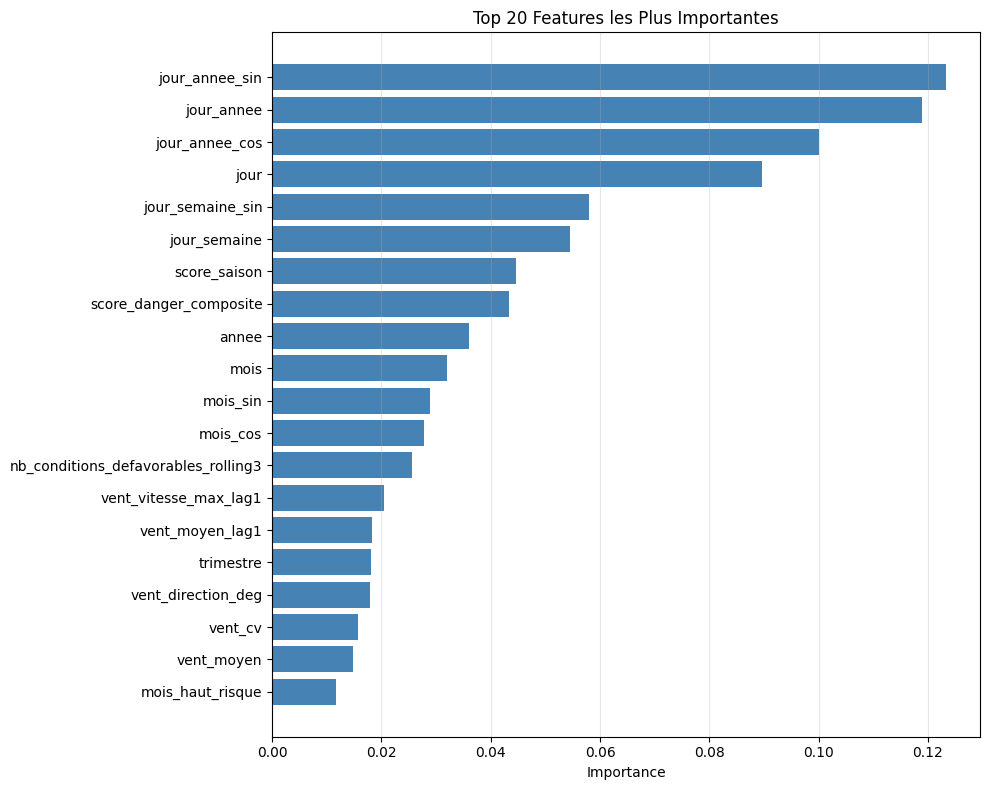


 Top 20 Features (XGBoost Optimisé):
                            feature  importance
                 vent_precipitation    0.063820
                   mois_haut_risque    0.061034
                            vent_cv    0.047175
                           mois_sin    0.045570
                               mois    0.044451
                     jour_annee_cos    0.042363
                       score_saison    0.040509
                              annee    0.040310
                   vent_vitesse_min    0.039561
                         jour_annee    0.034810
                               jour    0.033346
                   jour_semaine_sin    0.033172
                       jour_semaine    0.032772
                     jour_annee_sin    0.031455
                         vent_moyen    0.031373
                 vent_direction_deg    0.029826
              vent_vitesse_max_lag1    0.029443
                    vent_moyen_lag1    0.028719
nb_conditions_defavorables_rolling3    0.027859
  

In [22]:
# 8.1 Importance des Features (Random Forest / XGBoost)
print(" IMPORTANCE DES FEATURES")
print("=" * 60)

# Utiliser le meilleur modèle avec importance des features
if hasattr(best_rf, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n Top 20 Features (Random Forest Optimisé):")
    print(importance_df.head(20).to_string(index=False))
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = 20
    
    ax.barh(importance_df['feature'].head(top_n)[::-1], 
            importance_df['importance'].head(top_n)[::-1],
            color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Features les Plus Importantes')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Importance des features XGBoost
if hasattr(best_xgb, 'feature_importances_'):
    importance_xgb = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n Top 20 Features (XGBoost Optimisé):")
    print(importance_xgb.head(20).to_string(index=False))

### 5.2 Valeurs SHAP (Interprétabilité Avancée)

 ANALYSE SHAP - Explication des prédictions
Calcul des valeurs SHAP (peut prendre quelques secondes)...

 Graphique Récapitulatif SHAP:


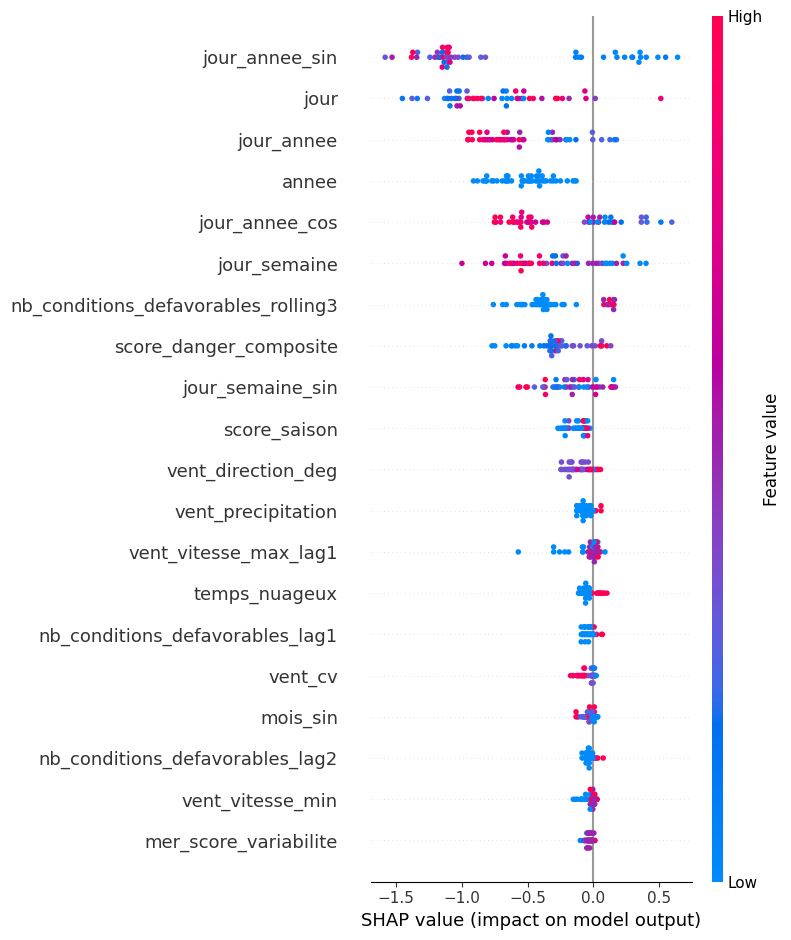


 Importance des Features SHAP (moyenne absolue):


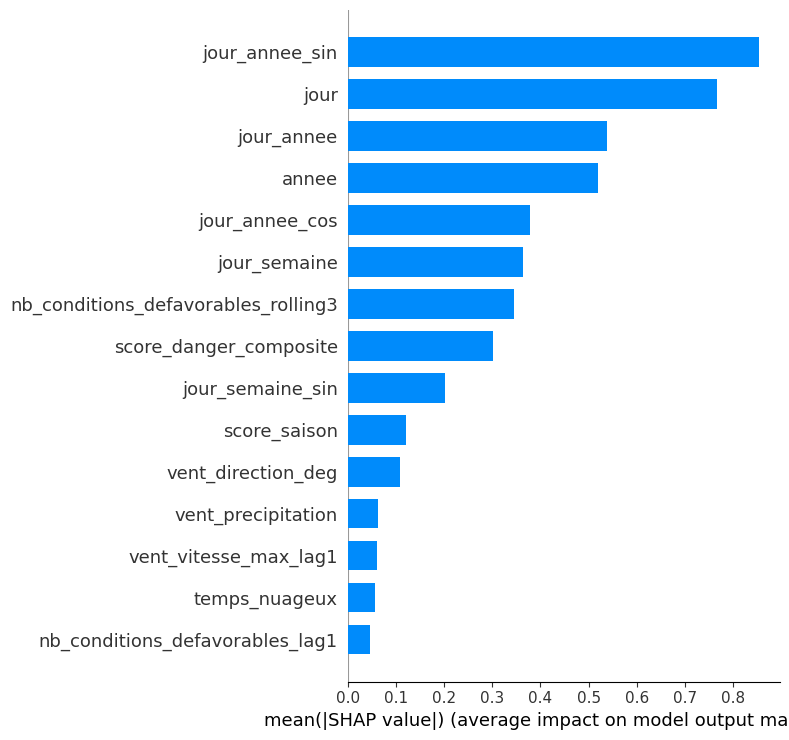

 Analyse SHAP terminée


In [23]:
# 8.2 Valeurs SHAP (Interprétabilité avancée)
print(" ANALYSE SHAP - Explication des prédictions")
print("=" * 60)

try:
    
    
    # Créer l'explainer pour le meilleur modèle (XGBoost ou RF)
    print("Calcul des valeurs SHAP (peut prendre quelques secondes)...")
    
    # Utiliser XGBoost pour SHAP (plus rapide)
    explainer = shap.TreeExplainer(best_xgb)
    
    # Calculer les valeurs SHAP sur un échantillon du test
    sample_size = min(50, len(X_test_scaled))
    X_test_sample = X_test_scaled[:sample_size]
    shap_values = explainer.shap_values(X_test_sample)
    
    # Graphique récapitulatif
    print("\n Graphique Récapitulatif SHAP:")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_sample, 
                      feature_names=feature_cols, 
                      show=False, max_display=20)
    plt.tight_layout()
    plt.show()
    
    # Graphique en barres des importances moyennes
    print("\n Importance des Features SHAP (moyenne absolue):")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_sample, 
                      feature_names=feature_cols,
                      plot_type='bar', show=False, max_display=15)
    plt.tight_layout()
    plt.show()
    
    print(" Analyse SHAP terminée")
    
except ImportError:
    print(" SHAP non installé. Installez avec: pip install shap")
except Exception as e:
    print(f" Erreur SHAP: {e}")
    print("   Continuons avec les autres analyses...")

## 5.3 Visualisations Comparatives


 VISUALISATION DES PERFORMANCES


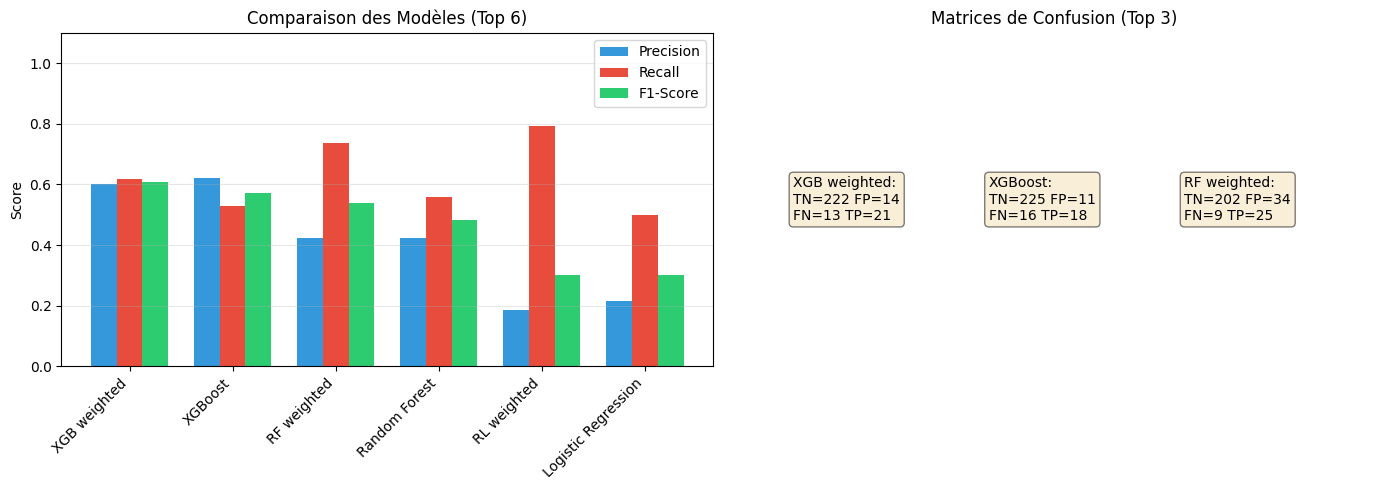

In [24]:
# 7.2 Visualisation comparative
print("\n VISUALISATION DES PERFORMANCES")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart des métriques
models_names = summary_df['Modèle'].tolist()[:6]  # Top 6
x = np.arange(len(models_names))
width = 0.25

ax1 = axes[0]
bars1 = ax1.bar(x - width, summary_df['Precision'].head(6), width, label='Precision', color='#3498db')
bars2 = ax1.bar(x, summary_df['Recall'].head(6), width, label='Recall', color='#e74c3c')
bars3 = ax1.bar(x + width, summary_df['F1-Score'].head(6), width, label='F1-Score', color='#2ecc71')

ax1.set_ylabel('Score')
ax1.set_title('Comparaison des Modèles (Top 6)')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# Matrices de confusion des 3 meilleurs
ax2 = axes[1]
top3 = summary_df.head(3)['Modèle'].tolist()

for i, name in enumerate(top3):
    if name in final_results:
        y_pred = final_results[name]['y_pred']
        cm = confusion_matrix(y_test, y_pred)
        ax2.text(0.1 + i*0.3, 0.5, f"{name}:\nTN={cm[0,0]} FP={cm[0,1]}\nFN={cm[1,0]} TP={cm[1,1]}", 
                 transform=ax2.transAxes, fontsize=10, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_title('Matrices de Confusion (Top 3)')
ax2.axis('off')

plt.tight_layout()
plt.show()

### 5.4 Courbes ROC

 COURBES ROC


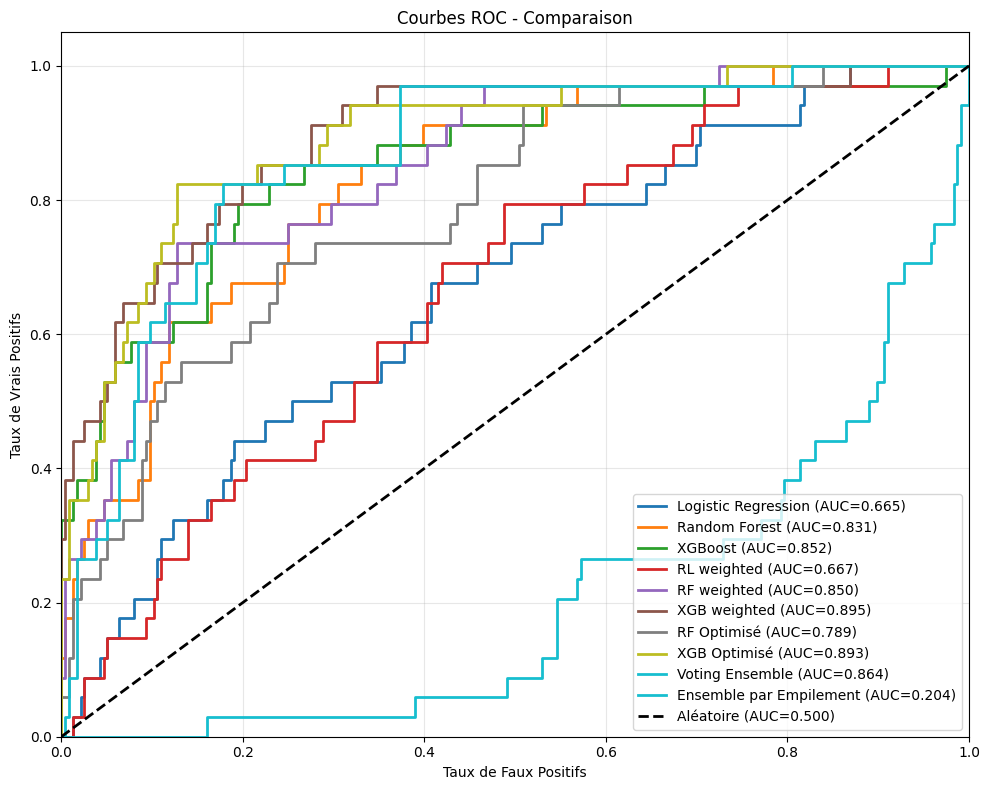

In [25]:
# 7.3 Courbes ROC (pour les modèles avec probabilités)
print(" COURBES ROC")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(final_results)))

for idx, (name, res) in enumerate(final_results.items()):
    if 'y_proba' in res:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        ax.plot(fpr, tpr, color=colors[idx], lw=2, 
                label=f'{name} (AUC={res["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Aléatoire (AUC=0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC - Comparaison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. DÉPLOIEMENT ET MAINTENANCE DU MODÈLE


### 6.1 Sauvegarde du Modèle Final

In [26]:
# 8.1 Sauvegarde du meilleur modèle

## Sauvegarder le modèle
best_model = final_results[best_model_name]['model']
model_filename = f'../api/best_model_{best_model_name.lower().replace(" ", "_")}.joblib'

## Sauvegarder le pipeline complet (scaler + modèle)
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'threshold': final_results[best_model_name].get('threshold', 0.5),
    'metrics': {
        'f1': final_results[best_model_name]['f1'],
        'recall': final_results[best_model_name]['recall'],
        'precision': final_results[best_model_name]['precision']
    }
}

joblib.dump(model_package, model_filename)
print(f" Modèle sauvegardé: {model_filename}")

## Sauvegarder aussi les infos
joblib.dump({
    'feature_columns': feature_cols,
    'best_model_name': best_model_name,
    'threshold': final_results[best_model_name].get('threshold', 0.5),
    'all_results': {k: {kk: vv for kk, vv in v.items() if kk not in ['model', 'y_pred', 'y_proba']} 
                   for k, v in final_results.items()}
}, '../api/model_features_info.joblib')
print(f" Infos sauvegardées: model_features_info.joblib")

 Modèle sauvegardé: ../api/best_model_xgb_weighted.joblib
 Infos sauvegardées: model_features_info.joblib


### 6.2 Conclusion et Recommandations

In [27]:
# 8.2 Conclusion et Recommandations
print("=" * 60)
print(" CONCLUSION ET RECOMMANDATIONS")
print("=" * 60)

# Calculer les stats depuis les données train+test
total_obs = len(train) + len(test)
total_incidents = train['incident'].sum() + test['incident'].sum()
incident_rate = total_incidents / total_obs

print(f"""
 RÉSUMÉ DU PROJET:
   - Dataset total: {total_obs} jours
   - Jours avec incident: {total_incidents} ({100*incident_rate:.1f}%)
   - Ratio: {int((1-incident_rate)/incident_rate)}:1

 MEILLEUR MODÈLE: {best_model_name}
   - F1-Score: {final_results[best_model_name]['f1']:.4f}
   - Recall: {final_results[best_model_name]['recall']:.4f}  
   - Precision: {final_results[best_model_name]['precision']:.4f}
   - Seuil: {final_results[best_model_name].get('threshold', 0.5)}

 INTERPRÉTATION:
   - Recall = % d'incidents réels détectés
   - Precision = % de prédictions "incident" qui sont correctes
   - F1 = équilibre entre Recall et Precision

 CONSIDÉRATIONS:
   - Le modèle prédit le RISQUE d'incident basé sur les conditions météo
   - Un jour "à risque" ne signifie pas qu'un incident va se produire
   - Utilisez ce modèle comme système d'ALERTE précoce

 UTILISATION RECOMMANDÉE:
   - Privilégier le RECALL pour ne pas manquer d'incidents
   - Accepter quelques fausses alertes (faux positifs)
   - Combiner avec le jugement humain expert

 MODÉLISATION TERMINÉE!
""")

 CONCLUSION ET RECOMMANDATIONS

 RÉSUMÉ DU PROJET:
   - Dataset total: 1346 jours
   - Jours avec incident: 168 (12.5%)
   - Ratio: 7:1

 MEILLEUR MODÈLE: XGB weighted
   - F1-Score: 0.6087
   - Recall: 0.6176  
   - Precision: 0.6000
   - Seuil: 0.40000000000000013

 INTERPRÉTATION:
   - Recall = % d'incidents réels détectés
   - Precision = % de prédictions "incident" qui sont correctes
   - F1 = équilibre entre Recall et Precision

 CONSIDÉRATIONS:
   - Le modèle prédit le RISQUE d'incident basé sur les conditions météo
   - Un jour "à risque" ne signifie pas qu'un incident va se produire
   - Utilisez ce modèle comme système d'ALERTE précoce

 UTILISATION RECOMMANDÉE:
   - Privilégier le RECALL pour ne pas manquer d'incidents
   - Accepter quelques fausses alertes (faux positifs)
   - Combiner avec le jugement humain expert

 MODÉLISATION TERMINÉE!

